[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


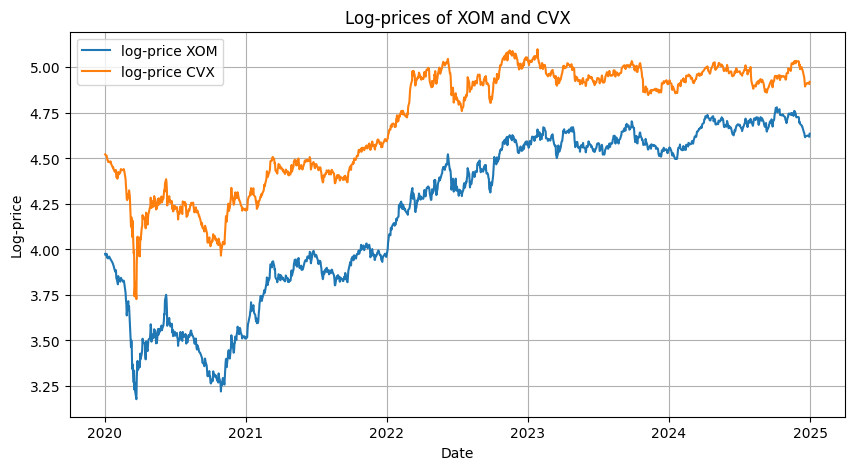

===== Cointegrating Regression =====
                            OLS Regression Results                            
Dep. Variable:                    XOM   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                 2.693e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:30:14   Log-Likelihood:                 1160.9
No. Observations:                1258   AIC:                            -2318.
Df Residuals:                    1256   BIC:                            -2307.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -

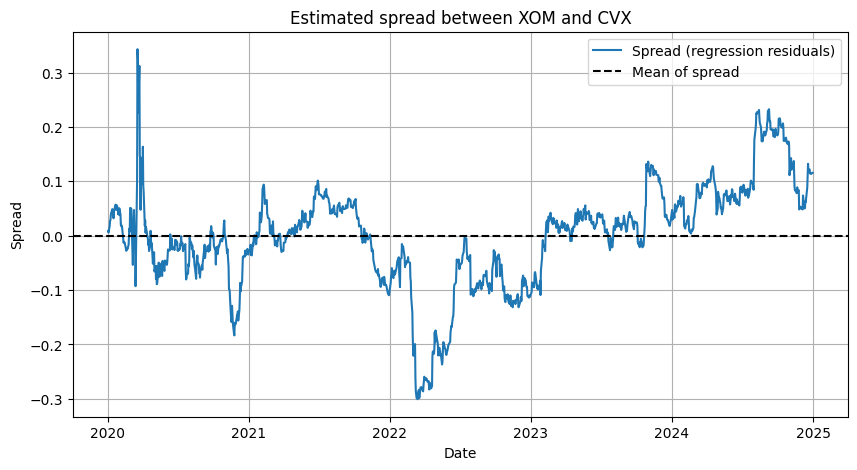

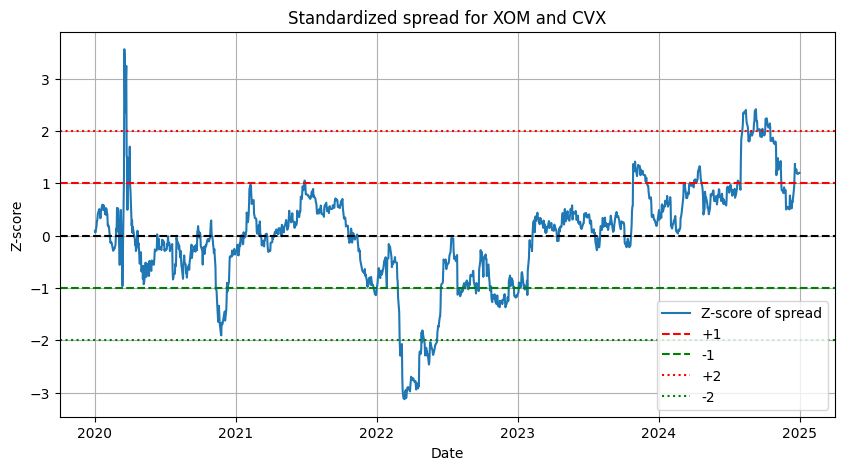

===== Interpretation =====
We regress log-prices to estimate the coefficient that defines the spread.
The residual from this regression is the estimated spread.

If the spread is stationary, then the two series are cointegrated.
This would suggest a stable long-run relationship between the two prices.

A large positive spread means that XOM looks expensive relative to CVX.
A large negative spread means that XOM looks cheap relative to CVX.
This is the basic idea behind pairs trading, although real trading
would also require transaction costs, risk controls, and out-of-sample validation.


In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

# -----------------------------
# 1. Download data
# -----------------------------
start_date = "2020-01-01"
end_date = "2025-01-01"

A = "XOM"   # Exxon Mobil
B = "CVX"   # Chevron

data_A = yf.download(A, start=start_date, end=end_date, auto_adjust=True)
data_B = yf.download(B, start=start_date, end=end_date, auto_adjust=True)

price_A = data_A["Close"].copy()
price_B = data_B["Close"].copy()

# -----------------------------
# 2. Align dates and keep only common observations
# -----------------------------
data = pd.concat([price_A, price_B], axis=1, join="inner")
data.columns = [A, B]
data = data.dropna()

# Use log-prices
log_data = np.log(data)

# -----------------------------
# 3. Plot the two log-price series
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(log_data.index, log_data[A], label=f"log-price {A}")
plt.plot(log_data.index, log_data[B], label=f"log-price {B}")
plt.title(f"Log-prices of {A} and {B}")
plt.xlabel("Date")
plt.ylabel("Log-price")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 4. Helper function: ADF test
# -----------------------------
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"===== ADF Test for {name} =====")
    print(f"Test statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print("Critical values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.6f}")
    if result[1] < 0.05:
        print(f"Conclusion: reject unit root for {name} (series looks stationary)")
    else:
        print(f"Conclusion: fail to reject unit root for {name} (series looks non-stationary)")
    print()

# Optional: uncomment if you want to test the individual log-prices
# adf_test(log_data[A], f"log-price {A}")
# adf_test(log_data[B], f"log-price {B}")

# -----------------------------
# 5. Cointegrating regression
# -----------------------------
X = sm.add_constant(log_data[B])
model = sm.OLS(log_data[A], X).fit()

alpha = model.params["const"]
beta = model.params[B]

print("===== Cointegrating Regression =====")
print(model.summary())
print()
print("Estimated cointegrating relationship:")
print(f"log({A}) = {alpha:.6f} + {beta:.6f} * log({B}) + residual")
print()

# -----------------------------
# 6. Construct the spread (residuals)
# -----------------------------
spread = model.resid

# -----------------------------
# 7. ADF test on the spread
# -----------------------------
adf_test(spread, "cointegrating residuals / spread")

# -----------------------------
# 8. Direct Engle-Granger cointegration test
# -----------------------------
coint_stat, coint_pvalue, critical_values = coint(log_data[A], log_data[B])

print("===== Engle-Granger Cointegration Test =====")
print(f"Test statistic: {coint_stat:.6f}")
print(f"p-value: {coint_pvalue:.6f}")
print("Critical values:")
print(f"   1%: {critical_values[0]:.6f}")
print(f"   5%: {critical_values[1]:.6f}")
print(f"  10%: {critical_values[2]:.6f}")

if coint_pvalue < 0.05:
    print(f"Conclusion: {A} and {B} appear to be cointegrated.")
else:
    print(f"Conclusion: no strong evidence of cointegration between {A} and {B}.")
print()

# -----------------------------
# 9. Plot the raw spread
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(spread.index, spread, label="Spread (regression residuals)")
plt.axhline(spread.mean(), linestyle="dashed", color="black", label="Mean of spread")
plt.title(f"Estimated spread between {A} and {B}")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 10. Plot the standardized spread (z-score)
# -----------------------------
zscore_spread = (spread - spread.mean()) / spread.std()

plt.figure(figsize=(10, 5))
plt.plot(zscore_spread.index, zscore_spread, label="Z-score of spread")
plt.axhline(0, linestyle="dashed", color="black")
plt.axhline(1, linestyle="dashed", color="red", label="+1")
plt.axhline(-1, linestyle="dashed", color="green", label="-1")
plt.axhline(2, linestyle="dotted", color="red", label="+2")
plt.axhline(-2, linestyle="dotted", color="green", label="-2")
plt.title(f"Standardized spread for {A} and {B}")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 11. Simple interpretation
# -----------------------------
print("===== Interpretation =====")
print("We regress log-prices to estimate the coefficient that defines the spread.")
print("The residual from this regression is the estimated spread.")
print()
print("If the spread is stationary, then the two series are cointegrated.")
print("This would suggest a stable long-run relationship between the two prices.")
print()
print(f"A large positive spread means that {A} looks expensive relative to {B}.")
print(f"A large negative spread means that {A} looks cheap relative to {B}.")
print("This is the basic idea behind pairs trading, although real trading")
print("would also require transaction costs, risk controls, and out-of-sample validation.")